In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "fixed100_Friedman"

# Long chain behavior

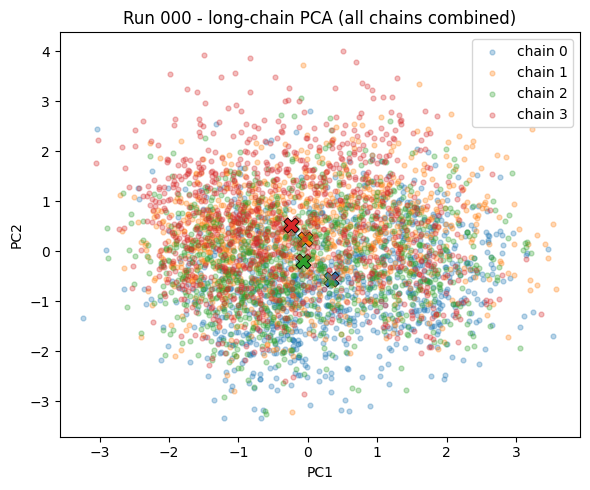

Run 000 centroids (PC1, PC2):
  chain 0: (0.3382, -0.5656)
  chain 1: (-0.0348, 0.2534)
  chain 2: (-0.0631, -0.2043)
  chain 3: (-0.2403, 0.5164)


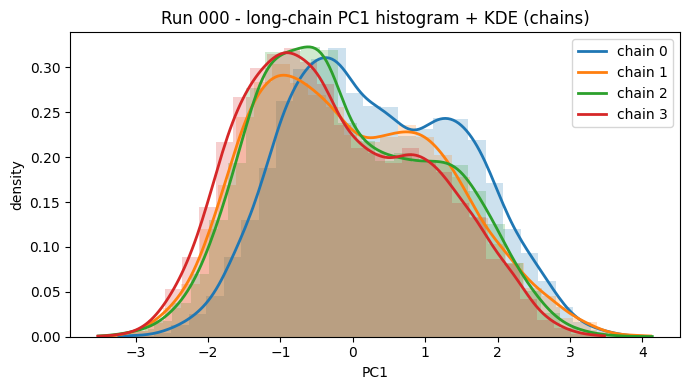

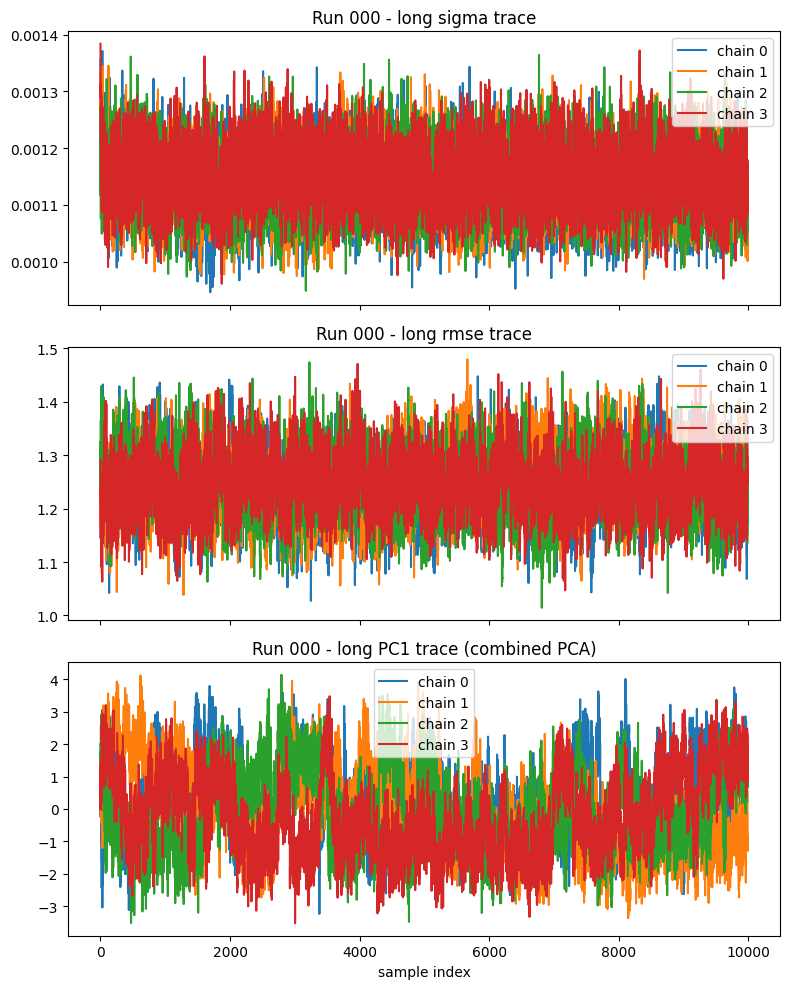

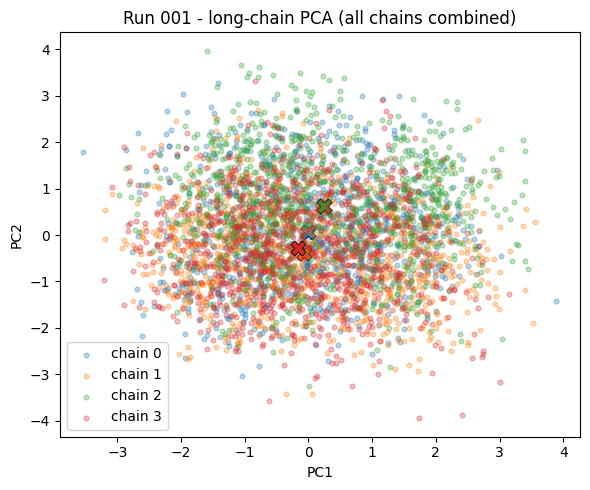

Run 001 centroids (PC1, PC2):
  chain 0: (-0.0151, 0.0622)
  chain 1: (-0.0626, -0.3939)
  chain 2: (0.2421, 0.6162)
  chain 3: (-0.1645, -0.2845)


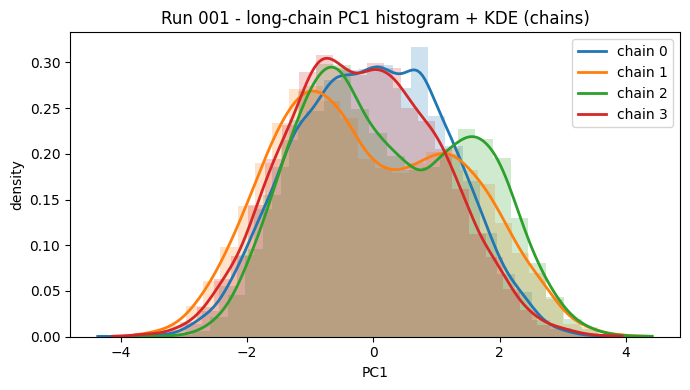

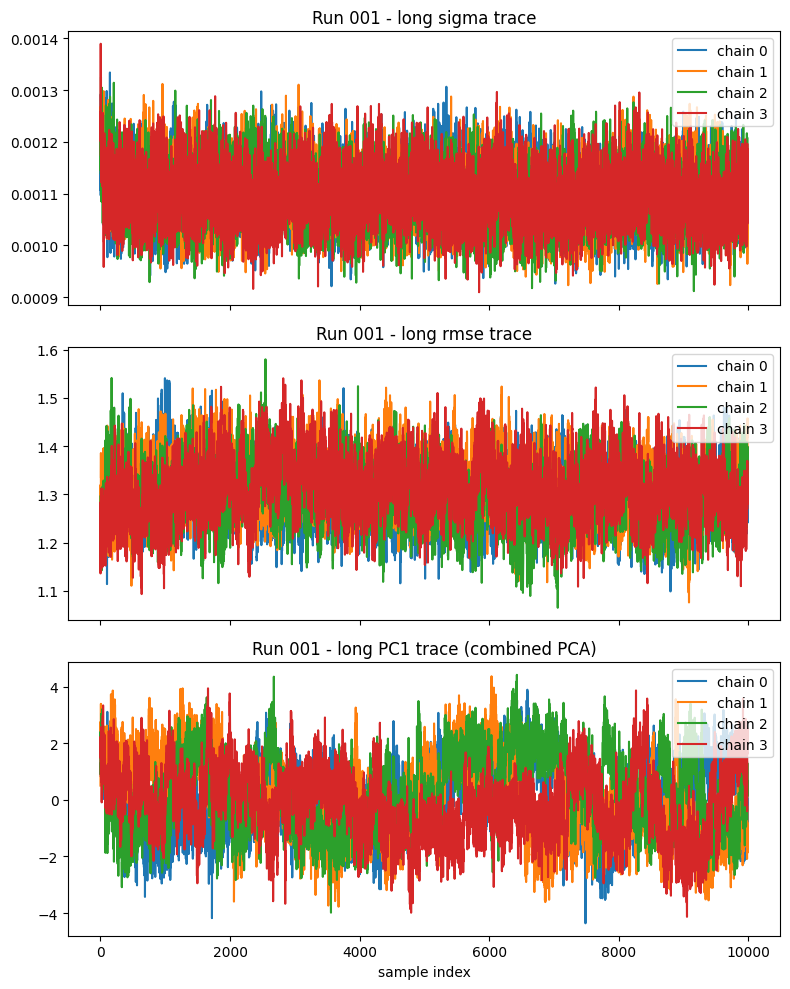

In [2]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints" / "store"
DATA_TAG = notebook
LONG_METHOD = "default_long"
RUN_IDS = [0, 1]  # update if you have more runs
LONG_BURN_IN = 10

DOWNSAMPLE_PER_CHAIN = 1000  # number of points per chain in PCA scatter
SCATTER_ALPHA = 0.3
CHAIN_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # high-contrast

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _load_long_array(run_id: int, metric: str):
    path = BASE_STORE / DATA_TAG / metric / f"{DATA_TAG}__run{run_id:03d}__{LONG_METHOD}__{metric}.csv"
    raw, shape = _load_with_shape(path)
    return raw.reshape(shape)

def _plot_pc1_hist_kde(pc1_groups, labels, colors, title):
    plt.figure(figsize=(7, 4))
    for data, label, color in zip(pc1_groups, labels, colors):
        data = np.asarray(data)
        plt.hist(
            data,
            bins=30,
            density=True,
            alpha=0.22,
            color=color,
            label="_nolegend_",
        )
        kde = gaussian_kde(data)
        xs = np.linspace(np.min(data), np.max(data), 200)
        plt.plot(xs, kde(xs), color=color, linewidth=2, label=label)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

for run_id in RUN_IDS:
    preds = _load_long_array(run_id, "preds")
    sigmas = _load_long_array(run_id, "sigmas")
    rmses = _load_long_array(run_id, "rmses")
    if LONG_BURN_IN > 0:
        sigmas = sigmas[:, LONG_BURN_IN:]
        rmses = rmses[:, LONG_BURN_IN:]
        preds = preds[:, :, LONG_BURN_IN:]

    n_chains = preds.shape[0]
    n_samples = preds.shape[2]
    colors = [CHAIN_COLORS[i % len(CHAIN_COLORS)] for i in range(n_chains)]

    # Fit PCA once per run using all chains together (all samples as rows).
    sample_vectors = preds.transpose(0, 2, 1).reshape(n_chains * n_samples, -1)
    pca = PCA(n_components=2, random_state=0)
    sample_coords = pca.fit_transform(sample_vectors)
    pc1 = sample_coords[:, 0].reshape(n_chains, n_samples)
    pc2 = sample_coords[:, 1].reshape(n_chains, n_samples)

    plt.figure(figsize=(6, 5))
    for c in range(n_chains):
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < n_samples:
            idx = np.linspace(0, n_samples - 1, DOWNSAMPLE_PER_CHAIN, dtype=int)
        else:
            idx = np.arange(n_samples)
        plt.scatter(
            pc1[c][idx],
            pc2[c][idx],
            color=colors[c],
            s=12,
            alpha=SCATTER_ALPHA,
            label=f"chain {c}",
        )
        centroid_x = np.mean(pc1[c])
        centroid_y = np.mean(pc2[c])
        plt.scatter(
            centroid_x,
            centroid_y,
            color=colors[c],
            s=120,
            marker="X",
            edgecolor="black",
            linewidth=0.6,
        )
    plt.title(f"Run {run_id:03d} - long-chain PCA (all chains combined)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Run {run_id:03d} centroids (PC1, PC2):")
    for c in range(n_chains):
        centroid_x = float(np.mean(pc1[c]))
        centroid_y = float(np.mean(pc2[c]))
        print(f"  chain {c}: ({centroid_x:.4f}, {centroid_y:.4f})")

    _plot_pc1_hist_kde(
        pc1_groups=[pc1[c] for c in range(n_chains)],
        labels=[f"chain {c}" for c in range(n_chains)],
        colors=colors,
        title=f"Run {run_id:03d} - long-chain PC1 histogram + KDE (chains)",
    )

    # Trace plots: sigmas, rmses, pc1 (PC1 from the combined PCA above)
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    for c in range(n_chains):
        axes[0].plot(sigmas[c], color=colors[c], label=f"chain {c}")
        axes[1].plot(rmses[c], color=colors[c], label=f"chain {c}")
        axes[2].plot(pc1[c], color=colors[c], label=f"chain {c}")
    axes[0].set_title(f"Run {run_id:03d} - long sigma trace")
    axes[1].set_title(f"Run {run_id:03d} - long rmse trace")
    axes[2].set_title(f"Run {run_id:03d} - long PC1 trace (combined PCA)")
    axes[2].set_xlabel("sample index")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()


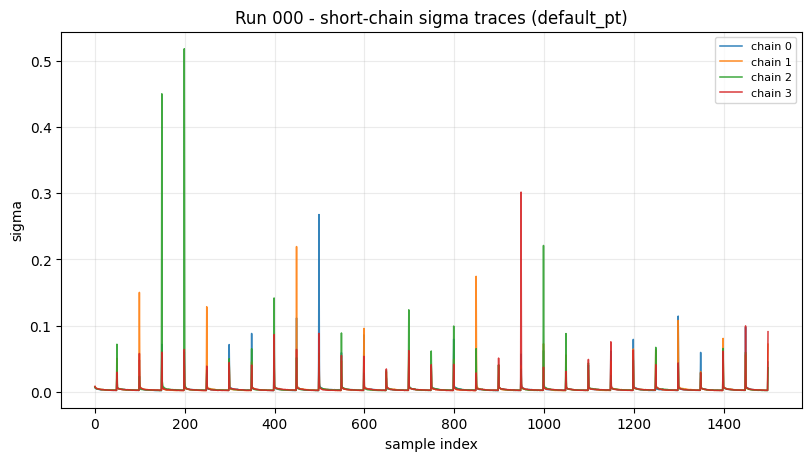

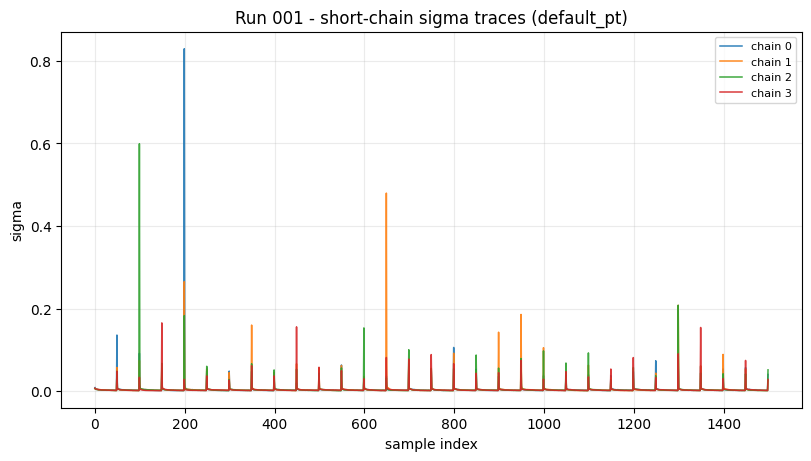

In [3]:
# Short-chain sigma trace plot for default_pt
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints" / "store"
DATA_TAG = notebook

TARGET_METHOD = "default_pt"
BURN_IN = 500

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _available_run_ids(method: str):
    sigmas_dir = BASE_STORE / DATA_TAG / "sigmas"
    run_ids = []
    for path in sigmas_dir.glob(f"{DATA_TAG}__run*__{method}__sigmas.csv"):
        parts = path.name.split("__run")
        if len(parts) < 2:
            continue
        run_fragment = parts[1].split("__", 1)[0]
        try:
            run_ids.append(int(run_fragment))
        except ValueError:
            continue
    return sorted(set(run_ids))

def _load_sigma_chains(run_id: int, method: str, burn_in: int = 0):
    sigma_path = BASE_STORE / DATA_TAG / "sigmas" / f"{DATA_TAG}__run{run_id:03d}__{method}__sigmas.csv"
    sigma_raw, sigma_shape = _load_with_shape(sigma_path)
    sigmas = np.asarray(sigma_raw).reshape(sigma_shape)
    if sigmas.ndim == 1:
        sigmas = sigmas[None, :]
    if burn_in > 0:
        sigmas = sigmas[:, burn_in:]
    return sigmas

run_ids = _available_run_ids(TARGET_METHOD)
if not run_ids:
    raise FileNotFoundError(f"No runs found for {TARGET_METHOD} sigma traces in {BASE_STORE / DATA_TAG}.")

for run_id in run_ids:
    fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
    sigmas = _load_sigma_chains(run_id, TARGET_METHOD, burn_in=BURN_IN)
    for chain_id in range(sigmas.shape[0]):
        ax.plot(sigmas[chain_id], linewidth=1.1, alpha=0.9, label=f"chain {chain_id}")
    ax.set_title(f"Run {run_id:03d} - short-chain sigma traces ({TARGET_METHOD})")
    ax.set_xlabel("sample index")
    ax.set_ylabel("sigma")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    plt.show()


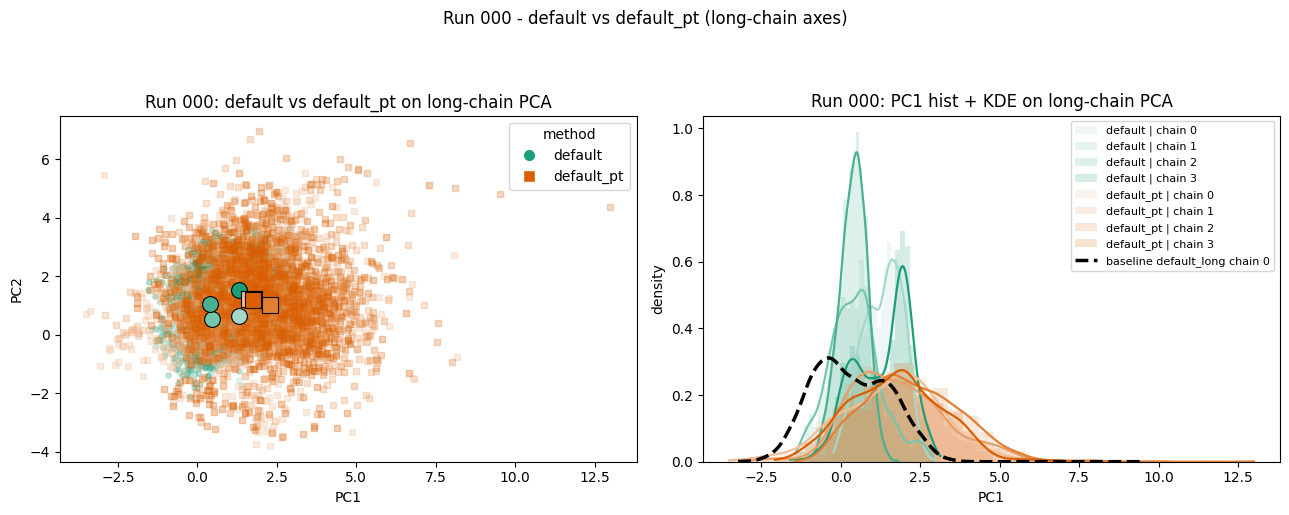

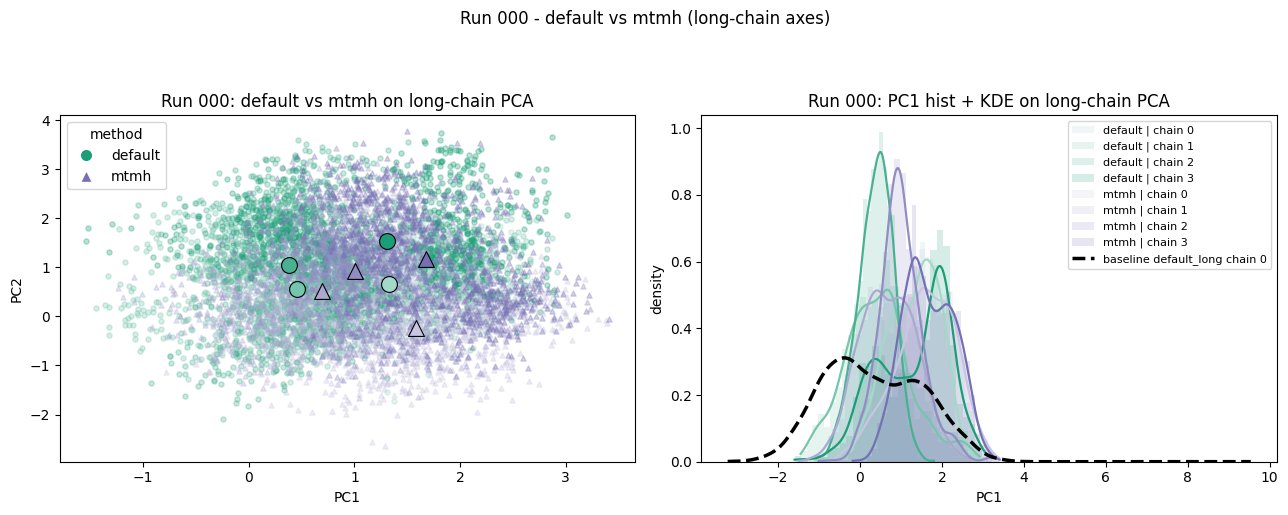

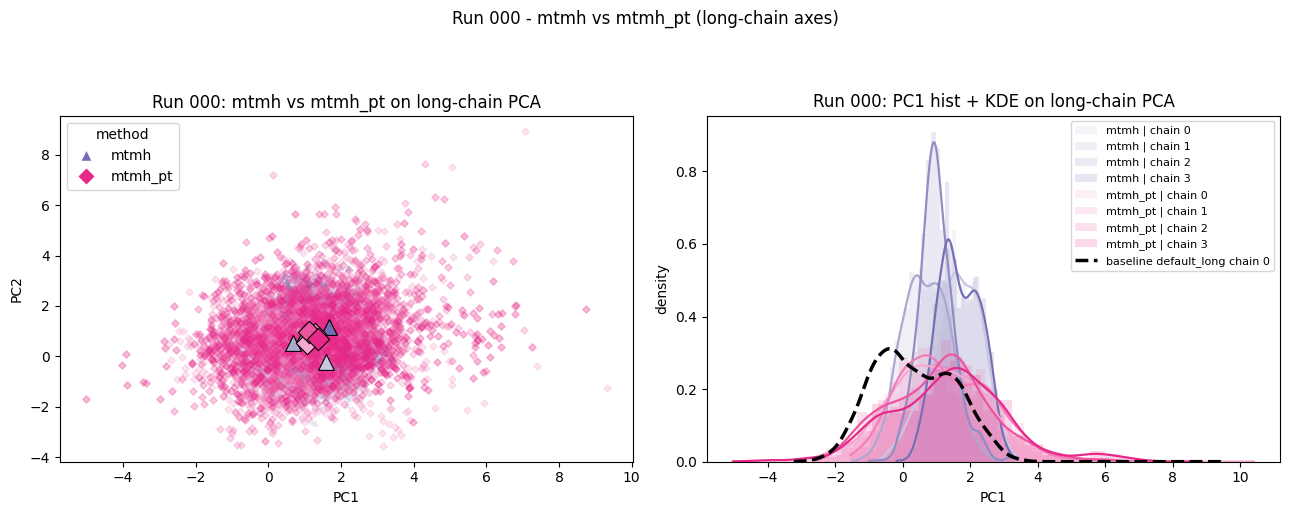

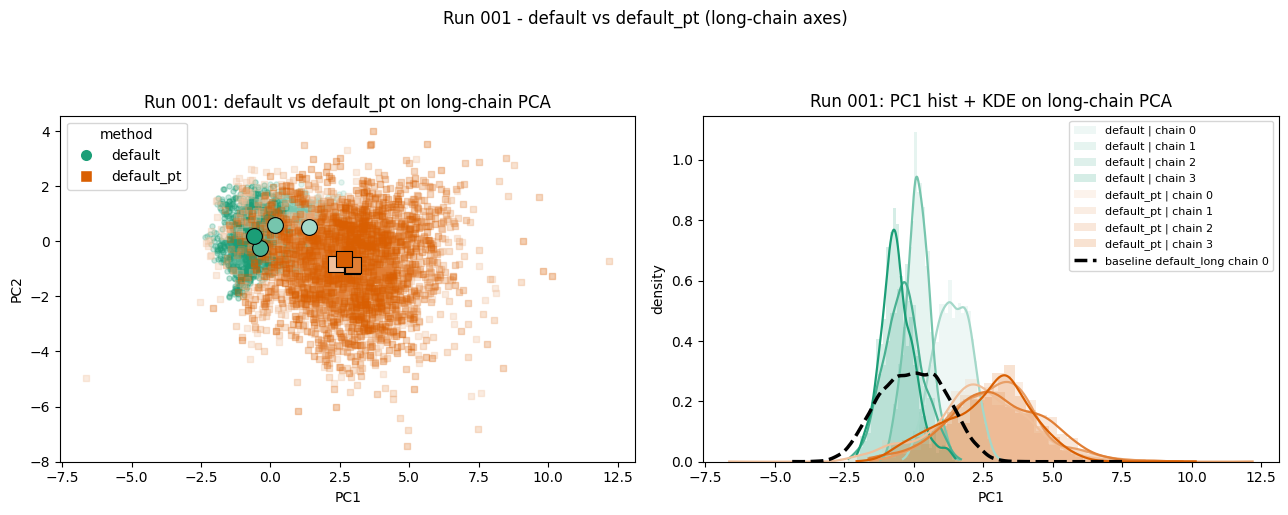

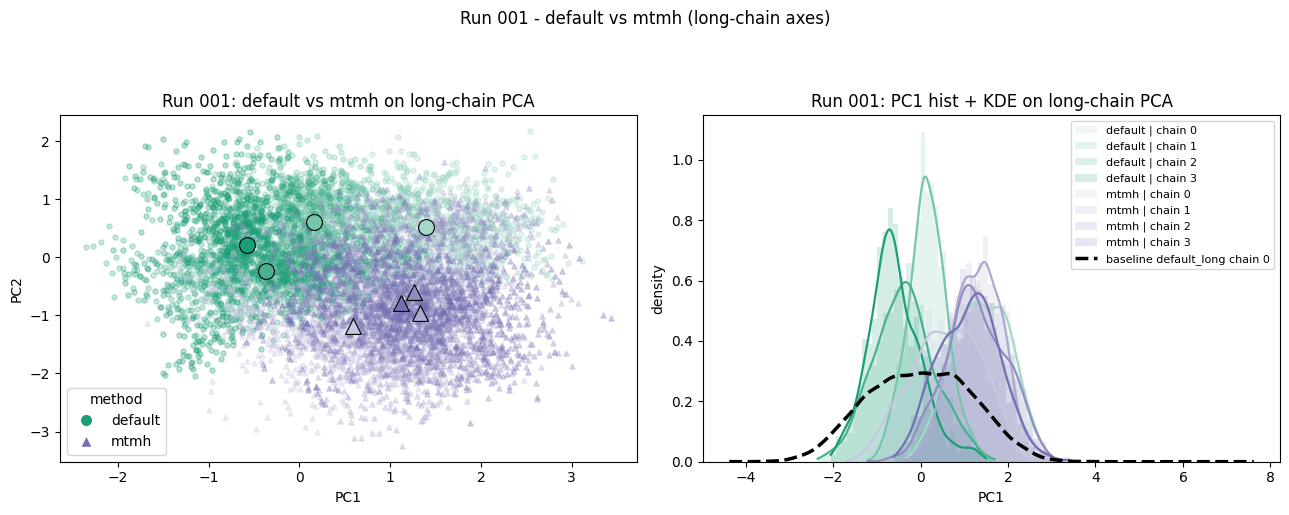

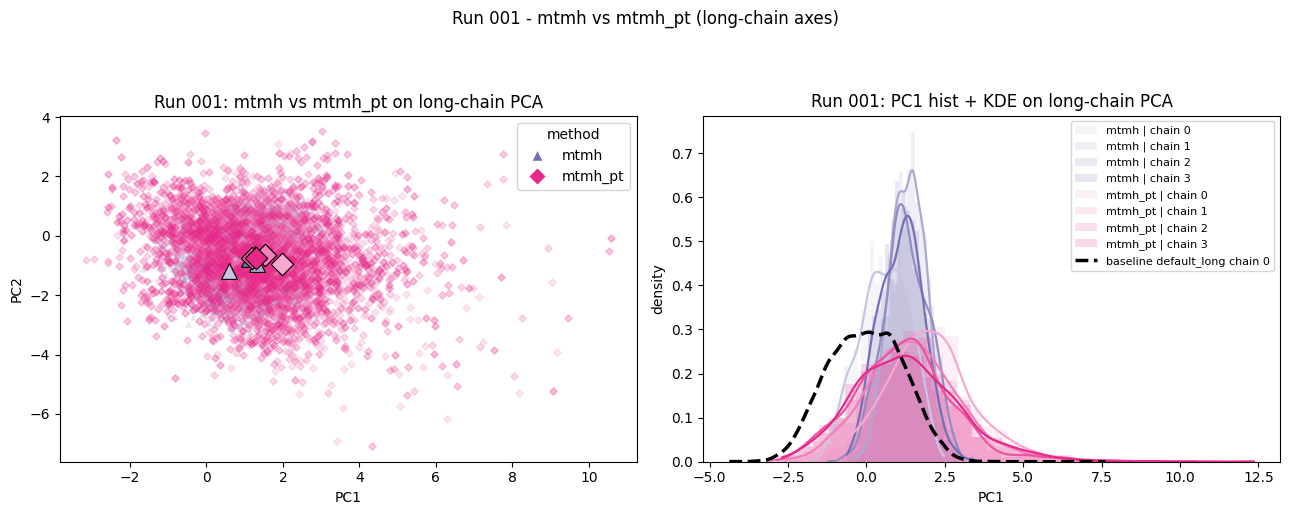

In [4]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints" / "store"
DATA_TAG = notebook

RUN_IDS = [0, 1]  # update if you have more runs
PAIRWISE_COMPARISONS = [
    ("default", "default_pt"),
    ("default", "mtmh"),
    ("mtmh", "mtmh_pt"),
]

BASELINE_METHOD = "default_long"
SHORT_BURN_IN = 500

DOWNSAMPLE_PER_CHAIN = 1000
SCATTER_ALPHA = 0.30
METHOD_MARKERS = {
    "default": "o",
    "default_pt": "s",
    "mtmh": "^",
    "mtmh_pt": "D",
}
METHOD_COLORS = {
    "default": "#1b9e77",
    "default_pt": "#d95f02",
    "mtmh": "#7570b3",
    "mtmh_pt": "#e7298a",
}

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _load_long_pred(run_id: int, method: str):
    preds_path = BASE_STORE / DATA_TAG / "preds" / f"{DATA_TAG}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    return preds_raw.reshape(preds_shape)

def _load_short_chains(run_id: int, method: str):
    preds_path = BASE_STORE / DATA_TAG / "preds" / f"{DATA_TAG}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if SHORT_BURN_IN > 0:
            chain_preds = chain_preds[:, SHORT_BURN_IN:]
        chains.append(chain_preds)
    return chains

def _fit_long_chain_pca(run_id: int):
    base_preds = _load_long_pred(run_id, BASELINE_METHOD)
    base_vectors = base_preds.transpose(0, 2, 1).reshape(base_preds.shape[0] * base_preds.shape[2], -1)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(base_vectors)
    baseline_pc1 = pca.transform(base_preds[0].T)[:, 0]
    return pca, baseline_pc1

def _method_chain_shades(base_hex, n):
    base = np.array(mcolors.to_rgb(base_hex))
    if n == 1:
        return [tuple(base)]
    shades = []
    for i in range(n):
        t = 0.4 + 0.6 * (i / max(1, n - 1))
        rgb = tuple(base * t + (1 - t) * np.array([1.0, 1.0, 1.0]))
        shades.append(rgb)
    return shades

def _plot_pc1_hist_kde(ax, items, title, baseline_pc1=None, baseline_label=None):
    for label, color, data in items:
        data = np.asarray(data)
        ax.hist(data, bins=30, density=True, alpha=0.18, color=color, label=label)
        try:
            kde = gaussian_kde(data)
            xs = np.linspace(np.min(data), np.max(data), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=1.6)
        except Exception:
            pass

    if baseline_pc1 is not None:
        baseline_pc1 = np.asarray(baseline_pc1)
        kde = gaussian_kde(baseline_pc1)
        xs = np.linspace(np.min(baseline_pc1), np.max(baseline_pc1), 200)
        ax.plot(xs, kde(xs), color="black", linewidth=2.5, linestyle="--", label=baseline_label or "baseline")

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)

def _scatter_method_chains(ax, pca, method_chains, method_name):
    marker = METHOD_MARKERS.get(method_name, "o")
    base_color = METHOD_COLORS.get(method_name, "#333333")
    n_chains = len(method_chains)
    shades = _method_chain_shades(base_color, n_chains)
    for chain_id, chain_preds in enumerate(method_chains):
        chain_color = shades[chain_id % len(shades)]
        coords = pca.transform(chain_preds.T)
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < coords.shape[0]:
            idx = np.linspace(0, coords.shape[0] - 1, DOWNSAMPLE_PER_CHAIN, dtype=int)
        else:
            idx = np.arange(coords.shape[0])
        ax.scatter(coords[idx, 0], coords[idx, 1], marker=marker, s=14, alpha=SCATTER_ALPHA, color=chain_color, label="_nolegend_")
        centroid = np.mean(coords, axis=0)
        ax.scatter(
            centroid[0],
            centroid[1],
            marker=marker,
            s=130,
            color=chain_color,
            edgecolor="black",
            linewidth=0.8,
            label=f"{method_name} | chain {chain_id}",
            zorder=5,
        )

for run_id in RUN_IDS:
    long_pca, baseline_pc1 = _fit_long_chain_pca(run_id)

    for method_a, method_b in PAIRWISE_COMPARISONS:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        method_a_chains = _load_short_chains(run_id, method_a)
        method_b_chains = _load_short_chains(run_id, method_b)
        method_groups = {method_a: method_a_chains, method_b: method_b_chains}

        for method_name, method_chains in method_groups.items():
            _scatter_method_chains(axes[0], long_pca, method_chains, method_name)

        axes[0].set_title(f"Run {run_id:03d}: {method_a} vs {method_b} on long-chain PCA")
        axes[0].set_xlabel("PC1")
        axes[0].set_ylabel("PC2")
        legend_handles = [
            Line2D(
                [0],
                [0],
                marker=METHOD_MARKERS[m],
                color="w",
                markerfacecolor=METHOD_COLORS[m],
                markersize=9,
                label=m,
            )
            for m in method_groups.keys()
        ]
        axes[0].legend(handles=legend_handles, title="method")

        items = []
        for method_name, method_chains in method_groups.items():
            base_color = METHOD_COLORS.get(method_name, "#333333")
            shades = _method_chain_shades(base_color, len(method_chains))
            for cidx, chain_preds in enumerate(method_chains):
                pc1 = long_pca.transform(chain_preds.T)[:, 0]
                items.append((f"{method_name} | chain {cidx}", shades[cidx % len(shades)], pc1))

        _plot_pc1_hist_kde(
            axes[1],
            items,
            title=f"Run {run_id:03d}: PC1 hist + KDE on long-chain PCA",
            baseline_pc1=baseline_pc1,
            baseline_label=f"baseline {BASELINE_METHOD} chain 0",
        )

        fig.suptitle(f"Run {run_id:03d} - {method_a} vs {method_b} (long-chain axes)", y=1.02)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


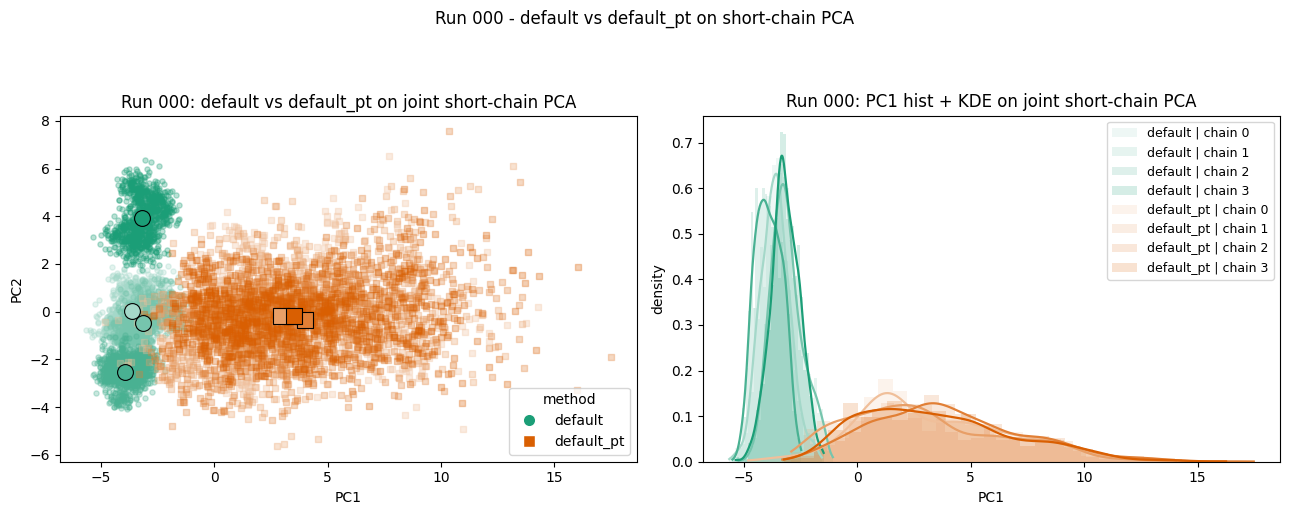

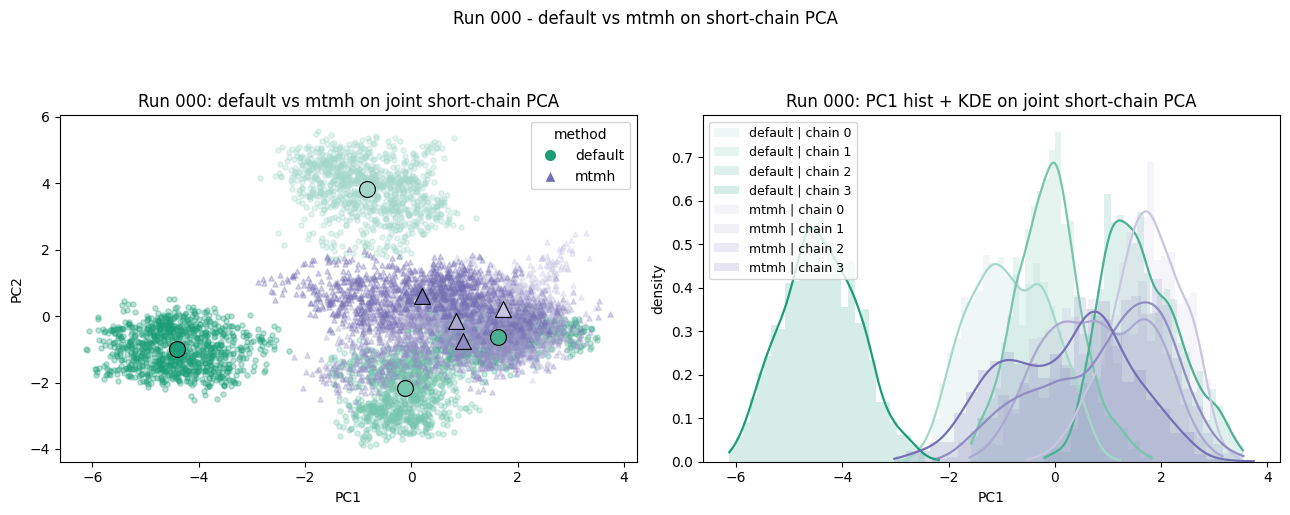

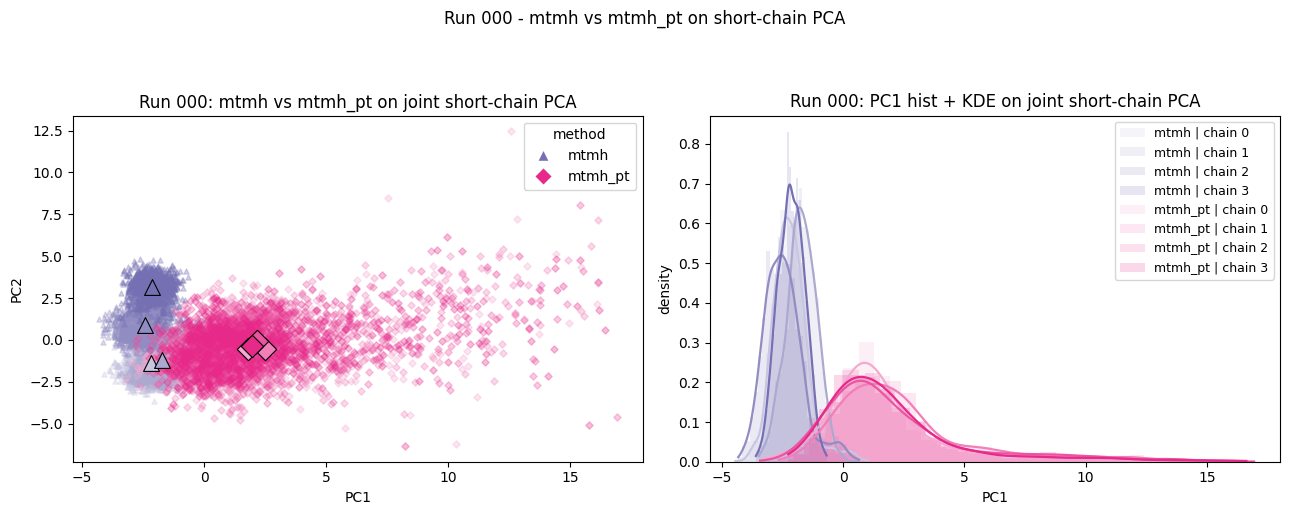

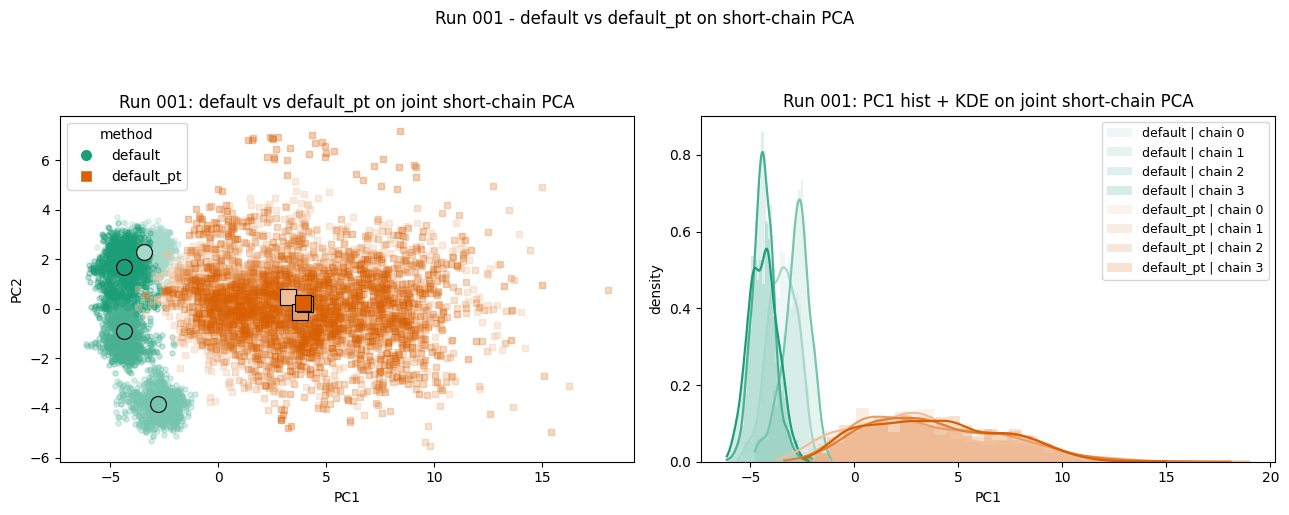

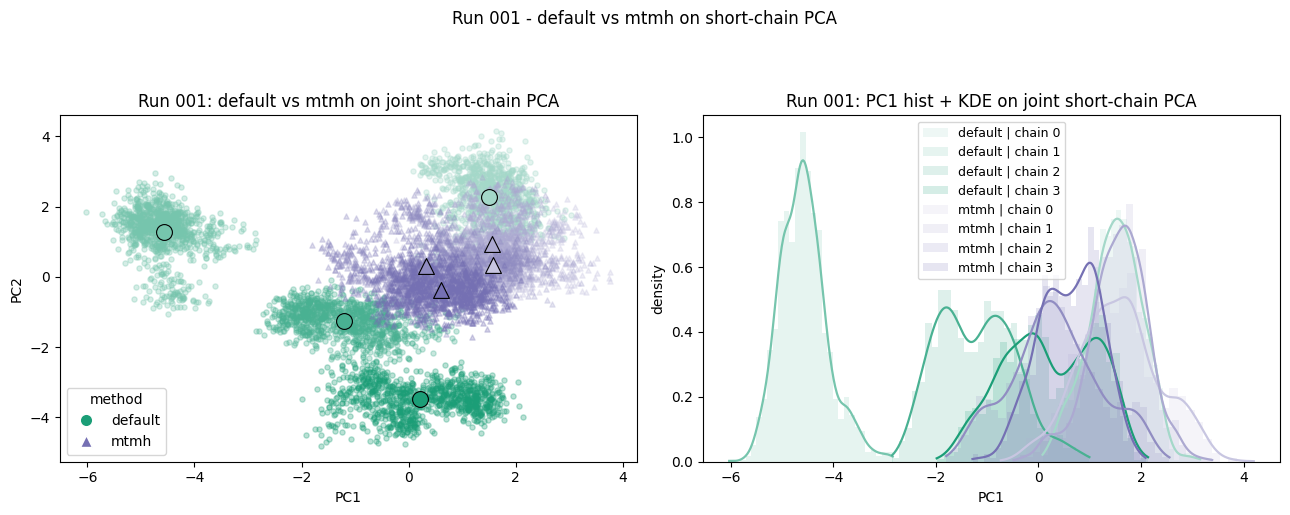

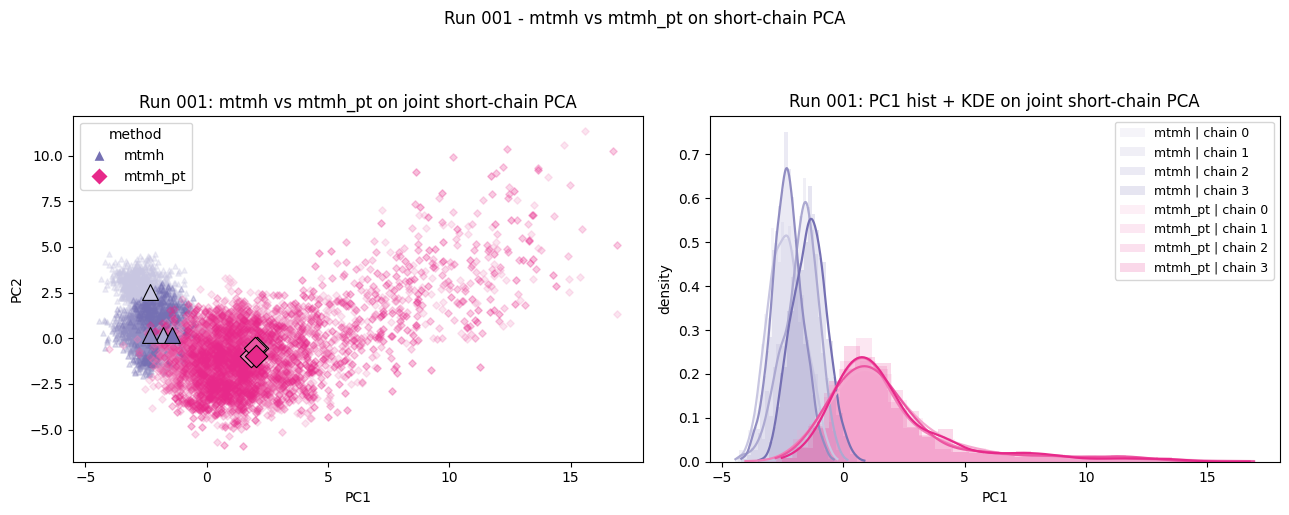

In [5]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints" / "store"
DATA_TAG = notebook

RUN_IDS = [0, 1]  # update if you have more runs
PAIRWISE_COMPARISONS = [
    ("default", "default_pt"),
    ("default", "mtmh"),
    ("mtmh", "mtmh_pt"),
]

BURN_IN = 500
DOWNSAMPLE_PER_CHAIN = 1000
SCATTER_ALPHA = 0.30
METHOD_MARKERS = {
    "default": "o",
    "default_pt": "s",
    "mtmh": "^",
    "mtmh_pt": "D",
}
METHOD_COLORS = {
    "default": "#1b9e77",
    "default_pt": "#d95f02",
    "mtmh": "#7570b3",
    "mtmh_pt": "#e7298a",
}

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _load_pred_chains(run_id: int, method: str):
    preds_path = BASE_STORE / DATA_TAG / "preds" / f"{DATA_TAG}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if BURN_IN > 0:
            chain_preds = chain_preds[:, BURN_IN:]
        chains.append(chain_preds)
    return preds, chains

def _fit_joint_short_pca(run_id: int, method_a: str, method_b: str):
    _, method_a_chains = _load_pred_chains(run_id, method_a)
    _, method_b_chains = _load_pred_chains(run_id, method_b)
    joint_blocks = [chain_preds.T for chain_preds in method_a_chains + method_b_chains]
    joint_predictions = np.vstack(joint_blocks)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(joint_predictions)
    return pca, {method_a: method_a_chains, method_b: method_b_chains}

def _method_chain_shades(base_hex, n):
    base = np.array(mcolors.to_rgb(base_hex))
    if n == 1:
        return [tuple(base)]
    shades = []
    for i in range(n):
        t = 0.4 + 0.6 * (i / max(1, n - 1))
        rgb = tuple(base * t + (1 - t) * np.array([1.0, 1.0, 1.0]))
        shades.append(rgb)
    return shades

def _plot_pc1_hist_kde(ax, items, title):
    for label, color, data in items:
        data = np.asarray(data)
        ax.hist(data, bins=30, density=True, alpha=0.18, color=color, label=label)
        try:
            kde = gaussian_kde(data)
            xs = np.linspace(np.min(data), np.max(data), 200)
            ax.plot(xs, kde(xs), color=color, linewidth=1.6)
        except Exception:
            pass

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("density")
    ax.legend(fontsize=9)

def _scatter_method_chains(ax, pca, method_chains, method_name, title):
    marker = METHOD_MARKERS.get(method_name, "o")
    base_color = METHOD_COLORS.get(method_name, "#333333")
    n_chains = len(method_chains)
    shades = _method_chain_shades(base_color, n_chains)
    for chain_id, chain_preds in enumerate(method_chains):
        chain_color = shades[chain_id % len(shades)]
        coords = pca.transform(chain_preds.T)
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < coords.shape[0]:
            idx = np.linspace(0, coords.shape[0] - 1, DOWNSAMPLE_PER_CHAIN, dtype=int)
        else:
            idx = np.arange(coords.shape[0])
        ax.scatter(coords[idx, 0], coords[idx, 1], marker=marker, s=14, alpha=SCATTER_ALPHA, color=chain_color, label="_nolegend_")
        centroid = np.mean(coords, axis=0)
        ax.scatter(
            centroid[0],
            centroid[1],
            marker=marker,
            s=130,
            color=chain_color,
            edgecolor="black",
            linewidth=0.8,
            label=f"{method_name} | chain {chain_id}",
            zorder=5,
        )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

for run_id in RUN_IDS:
    for method_a, method_b in PAIRWISE_COMPARISONS:
        joint_pca, method_groups = _fit_joint_short_pca(run_id, method_a, method_b)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        for method_name, method_chains in method_groups.items():
            _scatter_method_chains(
                axes[0],
                joint_pca,
                method_chains,
                method_name,
                title=f"Run {run_id:03d}: {method_a} vs {method_b} on joint short-chain PCA",
            )

        legend_handles = [
            Line2D([0], [0], marker=METHOD_MARKERS[m], color="w", markerfacecolor=METHOD_COLORS[m], markersize=9, label=m)
            for m in method_groups.keys()
        ]
        axes[0].legend(handles=legend_handles, title="method")

        items = []
        for method_name, method_chains in method_groups.items():
            base_color = METHOD_COLORS.get(method_name, "#333333")
            shades = _method_chain_shades(base_color, len(method_chains))
            for cidx, chain_preds in enumerate(method_chains):
                pc1 = joint_pca.transform(chain_preds.T)[:, 0]
                items.append((f"{method_name} | chain {cidx}", shades[cidx % len(shades)], pc1))

        _plot_pc1_hist_kde(
            axes[1],
            items,
            title=f"Run {run_id:03d}: PC1 hist + KDE on joint short-chain PCA",
        )

        fig.suptitle(f"Run {run_id:03d} - {method_a} vs {method_b} on short-chain PCA", y=1.02)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()


In [6]:
import ast
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

BASE_STORE = ROOT / "diagnosis" / "fixed100_testpoints" / "store"
DATA_TAG = notebook

LONG_METHOD = "default_long"
SHORT_METHODS = ["default", "default_pt", "mtmh", "mtmh_pt"]
SHORT_METHOD_NAMES = {
    "default": "Default",
    "default_pt": "Default PT",
    "mtmh": "MTMH",
    "mtmh_pt": "MTMH + PT",
}

LONG_BURN_IN = 10
SHORT_BURN_IN = 500

METHOD_LABELS = {
    "long_default": "Default long",
    "default": "Default (2k)",
    "default_pt": "Default PT (2k)",
    "mtmh": "MTMH (2k)",
    "mtmh_pt": "MTMH + PT (2k)",
}


def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape


def _crps_from_samples(samples, y_true):
    samples = np.asarray(samples)
    y_true = np.asarray(y_true)
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples**2)
    return term1 - term2


def _load_prediction_chains(base_store: Path, tag: str, run_id: int, method: str, burn_in: int):
    preds_path = base_store / tag / "preds" / f"{tag}__run{run_id:03d}__{method}__preds.csv"
    preds_raw, preds_shape = _load_with_shape(preds_path)
    preds = preds_raw.reshape(preds_shape)
    chains = []
    for chain_id in range(preds.shape[0]):
        chain_preds = preds[chain_id]
        if burn_in > 0:
            chain_preds = chain_preds[:, burn_in:]
        chains.append(chain_preds)
    return preds, chains


def _load_subsample_y(base_store: Path, tag: str, run_id: int):
    y_path = base_store / tag / "subsample_y_test" / f"{tag}__run{run_id:03d}__subsample_y_test.csv"
    y_raw, y_shape = _load_with_shape(y_path)
    return np.asarray(y_raw.reshape(y_shape)).reshape(-1)


def _available_run_ids(base_store: Path, tag: str, method: str):
    preds_dir = base_store / tag / "preds"
    run_ids = []
    for path in preds_dir.glob(f"{tag}__run*__{method}__preds.csv"):
        parts = path.name.split("__run")
        if len(parts) < 2:
            continue
        run_fragment = parts[1].split("__", 1)[0]
        try:
            run_ids.append(int(run_fragment))
        except ValueError:
            continue
    return sorted(set(run_ids))


def _chain_metric_row(chain_preds, y_true):
    y_pred = np.mean(chain_preds, axis=1)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    crps = float(np.mean(_crps_from_samples(chain_preds, y_true)))
    return rmse, crps


def _grouped_view(metric_df):
    long_col = METHOD_LABELS["long_default"]
    groups = {
        ("Long baseline", "Default long"): metric_df[long_col],
    }
    for method in SHORT_METHODS:
        short_label = SHORT_METHOD_NAMES[method]
        groups[("Short chain", short_label)] = metric_df[METHOD_LABELS[method]]
    grouped_df = pd.DataFrame(groups, index=metric_df.index)
    grouped_df.columns = pd.MultiIndex.from_tuples(grouped_df.columns)
    return grouped_df


run_id_sets = [set(_available_run_ids(BASE_STORE, DATA_TAG, LONG_METHOD))]
for method in SHORT_METHODS:
    run_id_sets.append(set(_available_run_ids(BASE_STORE, DATA_TAG, method)))
run_ids = sorted(set.intersection(*run_id_sets)) if run_id_sets else []
if not run_ids:
    raise FileNotFoundError("No overlapping runs found for long-chain baseline and short-chain methods.")

rmse_rows = []
crps_rows = []

for run_id in run_ids:
    y_true = _load_subsample_y(BASE_STORE, DATA_TAG, run_id)

    rmse_row = {"run": f"Run {run_id:03d}"}
    crps_row = {"run": f"Run {run_id:03d}"}

    _, long_chains = _load_prediction_chains(
        BASE_STORE, DATA_TAG, run_id, LONG_METHOD, LONG_BURN_IN
    )
    long_rmse_vals = []
    long_crps_vals = []
    for chain_preds in long_chains:
        rmse_val, crps_val = _chain_metric_row(chain_preds, y_true)
        long_rmse_vals.append(rmse_val)
        long_crps_vals.append(crps_val)
    rmse_row[METHOD_LABELS["long_default"]] = float(np.mean(long_rmse_vals))
    crps_row[METHOD_LABELS["long_default"]] = float(np.mean(long_crps_vals))

    for method in SHORT_METHODS:
        _, short_chains = _load_prediction_chains(
            BASE_STORE, DATA_TAG, run_id, method, SHORT_BURN_IN
        )
        rmse_vals = []
        crps_vals = []
        for chain_preds in short_chains:
            rmse_val, crps_val = _chain_metric_row(chain_preds, y_true)
            rmse_vals.append(rmse_val)
            crps_vals.append(crps_val)
        label = METHOD_LABELS[method]
        rmse_row[label] = float(np.mean(rmse_vals))
        crps_row[label] = float(np.mean(crps_vals))

    rmse_rows.append(rmse_row)
    crps_rows.append(crps_row)

rmse_df = pd.DataFrame(rmse_rows).set_index("run")
crps_df = pd.DataFrame(crps_rows).set_index("run")

column_order = [METHOD_LABELS["long_default"]] + [METHOD_LABELS[m] for m in SHORT_METHODS]
rmse_df = rmse_df[column_order]
crps_df = crps_df[column_order]

rmse_grouped_df = _grouped_view(rmse_df)
crps_grouped_df = _grouped_view(crps_df)

print("RMSE (grouped view)")
display(rmse_grouped_df.round(4))
print("\nCRPS (grouped view)")
display(crps_grouped_df.round(4))

print("\nRMSE average across runs")
display(rmse_grouped_df.mean(axis=0).unstack(0).T.round(4))
print("\nCRPS average across runs")
display(crps_grouped_df.mean(axis=0).unstack(0).T.round(4))


RMSE (grouped view)


Long baseline Short chain                             
         Default long     Default Default PT    MTMH MTMH + PT
run                                                           
Run 000        1.0991      1.1821     1.2487  1.1155    1.0807
Run 001        1.1553      1.1608     1.2821  1.1832    1.1301


CRPS (grouped view)


Long baseline Short chain                             
         Default long     Default Default PT    MTMH MTMH + PT
run                                                           
Run 000        0.6653      0.7586     0.7034  0.6934    0.6119
Run 001        0.6870      0.7279     0.7193  0.7418    0.6387


RMSE average across runs


,Default,Default PT,Default long,MTMH,MTMH + PT
Long baseline,NaN,NaN,1.1272,NaN,NaN
Short chain,1.1715,1.2654,NaN,1.1493,1.1054



CRPS average across runs


,Default,Default PT,Default long,MTMH,MTMH + PT
Long baseline,NaN,NaN,0.6761,NaN,NaN
Short chain,0.7432,0.7114,NaN,0.7176,0.6253


# Confidence Interval

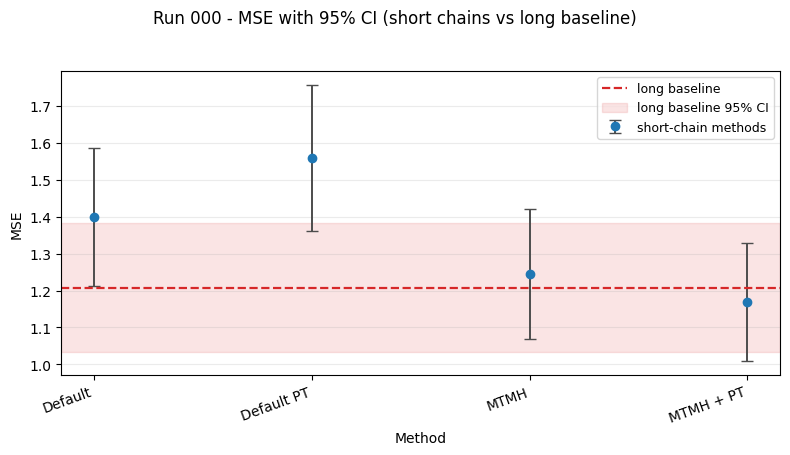

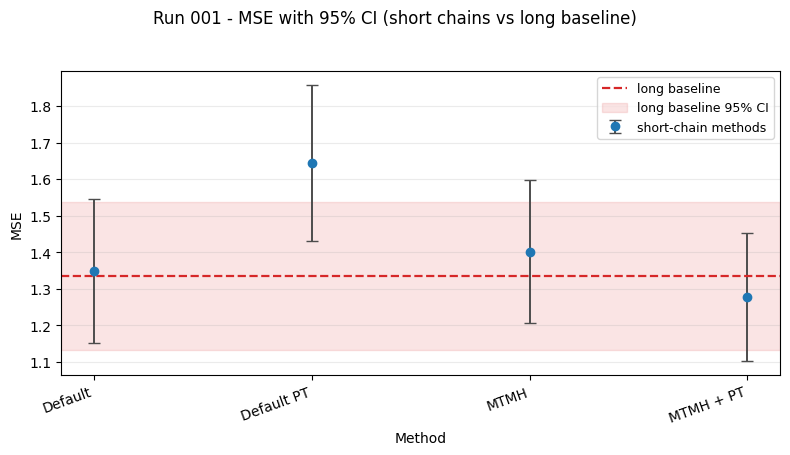

In [7]:
import matplotlib.pyplot as plt

Z_VALUE = 1.96
SHORT_METHOD_DISPLAY = {
    "default": "Default",
    "default_pt": "Default PT",
    "mtmh": "MTMH",
    "mtmh_pt": "MTMH + PT",
}

run_id_sets = [set(_available_run_ids(BASE_STORE, DATA_TAG, LONG_METHOD))]
for method in SHORT_METHODS:
    run_id_sets.append(set(_available_run_ids(BASE_STORE, DATA_TAG, method)))
run_ids = sorted(set.intersection(*run_id_sets)) if run_id_sets else []
if not run_ids:
    raise FileNotFoundError("No overlapping runs found for long-chain baseline and short-chain methods.")

def _mse_mean_ci(square_error_list):
    squared_errors = np.concatenate(square_error_list)
    mse_mean = float(np.mean(squared_errors))
    mse_std = float(np.std(squared_errors, ddof=1)) if squared_errors.size > 1 else 0.0
    ci_half_width = Z_VALUE * mse_std / np.sqrt(squared_errors.size) if squared_errors.size > 1 else 0.0
    return mse_mean, ci_half_width

for run_id in run_ids:
    y_true = _load_subsample_y(BASE_STORE, DATA_TAG, run_id)

    _, long_chains = _load_prediction_chains(
        BASE_STORE, DATA_TAG, run_id, LONG_METHOD, LONG_BURN_IN
    )
    long_sq_errors = []
    for chain_preds in long_chains:
        y_pred = np.mean(chain_preds, axis=1)
        long_sq_errors.append((y_pred - y_true) ** 2)
    baseline_mean, baseline_ci = _mse_mean_ci(long_sq_errors)

    fig, ax = plt.subplots(figsize=(8, 4.6))

    means = []
    cis = []
    for method in SHORT_METHODS:
        _, short_chains = _load_prediction_chains(
            BASE_STORE, DATA_TAG, run_id, method, SHORT_BURN_IN
        )
        method_sq_errors = []
        for chain_preds in short_chains:
            y_pred = np.mean(chain_preds, axis=1)
            method_sq_errors.append((y_pred - y_true) ** 2)
        m, c = _mse_mean_ci(method_sq_errors)
        means.append(m)
        cis.append(c)

    x = np.arange(len(SHORT_METHODS))
    ax.errorbar(
        x,
        means,
        yerr=cis,
        fmt="o",
        color="#1f77b4",
        ecolor="#4c4c4c",
        elinewidth=1.4,
        capsize=4,
        markersize=6,
        linewidth=0,
        label="short-chain methods",
    )

    ax.axhline(baseline_mean, color="#d62728", linestyle="--", linewidth=1.6, label="long baseline")
    ax.axhspan(
        baseline_mean - baseline_ci,
        baseline_mean + baseline_ci,
        color="#d62728",
        alpha=0.12,
        label="long baseline 95% CI",
    )

    ax.set_xticks(x)
    ax.set_xticklabels([SHORT_METHOD_DISPLAY[m] for m in SHORT_METHODS], rotation=20, ha="right")
    ax.set_ylabel("MSE")
    ax.set_xlabel("Method")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="best", fontsize=9)
    fig.suptitle(f"Run {run_id:03d} - MSE with 95% CI (short chains vs long baseline)")
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


# Energy distance (chain-level)

We use chain-level pairwise comparisons: each short-chain method is compared with the long-chain baseline across all 4x4 chain pairs, then summarized as mean (std).

Energy Distance measures how different two sample distributions are; larger values indicate larger differences in location/shape.

For two sample sets $X = \{x_1,\dots,x_n\}$ and $Y = \{y_1,\dots,y_m\}$ (each $x_i, y_j \in \mathbb{R}^d$), the squared Energy Distance is defined as:

$$
\widehat{\mathcal{E}}^2(X,Y) = \frac{2}{nm}\sum_{i=1}^{n}\sum_{j=1}^{m} \|x_i - y_j\| - \frac{1}{n(n-1)}\sum_{i\neq i'}\|x_i - x_{i'}\| - \frac{1}{m(m-1)}\sum_{j\neq j'}\|y_j - y_{j'}\|
$$

where $\|\cdot\|$ denotes the Euclidean distance. The first term measures the average cross-sample distance, while the latter two terms measure within-sample dispersions. This estimator excludes self-pairs (diagonals) from the within-sample terms.


In [8]:
# -------- Energy distance (chain-level 4x4 pairwise -> mean(std)) --------
ED_MAX_DRAWS_PER_CHAIN = 2000  # per pair, keeps O(n^2) cost manageable
SHORT_METHOD_DISPLAY = {
    "default": "Default",
    "default_pt": "Default PT",
    "mtmh": "MTMH",
    "mtmh_pt": "MTMH + PT",
}

def _stack_draw_vectors(chain_list):
    return [np.asarray(chain).T for chain in chain_list]  # each: (n_samples, n_points)

def _euclidean_dists(a, b):
    a2 = np.sum(a * a, axis=1, keepdims=True)
    b2 = np.sum(b * b, axis=1, keepdims=True).T
    d2 = np.maximum(a2 + b2 - 2.0 * (a @ b.T), 0.0)
    return np.sqrt(d2)

def _energy_distance(x, y):
    if x.shape[0] < 2 or y.shape[0] < 2:
        return np.nan
    d_xy = _euclidean_dists(x, y).mean()
    d_xx = _euclidean_dists(x, x).mean()
    d_yy = _euclidean_dists(y, y).mean()
    return float(2.0 * d_xy - d_xx - d_yy)

run_id_sets = [set(_available_run_ids(BASE_STORE, DATA_TAG, LONG_METHOD))]
for method in SHORT_METHODS:
    run_id_sets.append(set(_available_run_ids(BASE_STORE, DATA_TAG, method)))
run_ids = sorted(set.intersection(*run_id_sets)) if run_id_sets else []
if not run_ids:
    raise FileNotFoundError("No overlapping runs found for long-chain baseline and short-chain methods.")

rows = []
rng = np.random.default_rng(2028)

for run_id in run_ids:
    _, long_chains = _load_prediction_chains(
        BASE_STORE, DATA_TAG, run_id, LONG_METHOD, LONG_BURN_IN
    )
    long_draws = _stack_draw_vectors(long_chains)

    for method in SHORT_METHODS:
        _, short_chains = _load_prediction_chains(
            BASE_STORE, DATA_TAG, run_id, method, SHORT_BURN_IN
        )
        short_draws = _stack_draw_vectors(short_chains)

        pair_vals = []
        for s_chain in short_draws:
            for l_chain in long_draws:
                n_use = min(s_chain.shape[0], l_chain.shape[0], ED_MAX_DRAWS_PER_CHAIN)
                if n_use < 2:
                    continue
                s_idx = rng.choice(s_chain.shape[0], size=n_use, replace=False)
                l_idx = rng.choice(l_chain.shape[0], size=n_use, replace=False)
                pair_vals.append(_energy_distance(s_chain[s_idx], l_chain[l_idx]))

        pair_vals = np.asarray(pair_vals, dtype=float)
        mean_val = float(np.nanmean(pair_vals)) if pair_vals.size else np.nan
        std_val = float(np.nanstd(pair_vals, ddof=1)) if pair_vals.size > 1 else 0.0
        rows.append(
            {
                "run": f"Run {run_id:03d}",
                "method": SHORT_METHOD_DISPLAY[method],
                "mean": mean_val,
                "std": std_val,
                "display": f"{mean_val:.6f} ({std_val:.6f})",
            }
        )

ed_chain_df = pd.DataFrame(rows)
print("Energy distance (chain-level): mean (std) over 4x4 chain pairs")
wide = ed_chain_df.pivot(index="run", columns="method", values="display")
wide = wide.reindex(columns=[SHORT_METHOD_DISPLAY[m] for m in SHORT_METHODS])
display(wide)


Energy distance (chain-level): mean (std) over 4x4 chain pairs


method,Default,Default PT,MTMH,MTMH + PT
run,,,,
Run 000,3.368549 (0.727585),5.541769 (0.346449),2.005368 (0.498969),2.777985 (0.166461)
Run 001,3.069800 (0.377135),5.609097 (0.234850),2.102479 (0.246284),2.541475 (0.097005)


# LDA: Chain-Labeled Analysis

This section adds a supervised diagnostic using LDA where **chain id** is the class label within the same run.

- We fit LDA separately for each `(run, method)`.
- We compare four methods (`default`, `default_pt`, `mtmh`, `mtmh_pt`) under the same run.

Interpretation note: this is an exploratory chain-separation view in prediction space, not a formal convergence proof.


In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

LDA_MAX_DRAWS_PER_CHAIN = 1500
LDA_RANDOM_SEED = 2028
SHORT_METHOD_DISPLAY = {
    "default": "Default",
    "default_pt": "Default PT",
    "mtmh": "MTMH",
    "mtmh_pt": "MTMH + PT",
}


def _build_chain_labeled_matrix(run_id: int, method: str, max_draws_per_chain=None, seed=0):
    """Return X, y for LDA where labels are chain ids."""
    preds_raw, preds_chains = _load_prediction_chains(
        BASE_STORE, DATA_TAG, run_id, method, SHORT_BURN_IN
    )

    n_chains, n_points, n_draws = preds_raw.shape
    rng = np.random.default_rng(seed)

    blocks = []
    labels = []
    draw_ids = []

    for chain_id in range(n_chains):
        chain_preds = preds_chains[chain_id]  # (n_points, n_draws)
        available_draws = chain_preds.shape[1]
        if max_draws_per_chain is not None and max_draws_per_chain < available_draws:
            sel = np.sort(rng.choice(available_draws, size=max_draws_per_chain, replace=False))
        else:
            sel = np.arange(available_draws)

        block = chain_preds[:, sel].T  # (n_selected_draws, n_points)
        blocks.append(block)
        labels.append(np.full(block.shape[0], chain_id, dtype=int))
        draw_ids.append(sel)

    X = np.vstack(blocks)
    y = np.concatenate(labels)
    draw_idx = np.concatenate(draw_ids)
    return X, y, draw_idx


def _fit_chain_lda(X, y, n_components=2):
    classes = np.unique(y)
    if classes.size < 2:
        raise ValueError("LDA requires at least two chain classes.")

    max_components = min(classes.size - 1, X.shape[1])
    n_use = min(n_components, max_components)
    if n_use < 1:
        n_use = 1

    model = make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(n_components=n_use, solver="svd"),
    )
    Z = model.fit_transform(X, y)
    return Z, model


def _method_name(method_key: str):
    return SHORT_METHOD_DISPLAY.get(method_key, method_key)


def _chain_colors_for_method(method_key: str, n_chains: int):
    base_color = METHOD_COLORS.get(method_key, "#333333")
    return _method_chain_shades(base_color, n_chains)


def _chain_separation_metrics(Z, y):
    y = np.asarray(y)
    Z = np.asarray(Z)

    classes = np.unique(y)
    centroids = []
    within_vals = []

    for c in classes:
        points = Z[y == c]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
        within_vals.append(np.mean(np.sum((points - centroid) ** 2, axis=1)))

    centroids = np.vstack(centroids)
    if centroids.shape[0] > 1:
        pairwise = []
        for i in range(centroids.shape[0]):
            for j in range(i + 1, centroids.shape[0]):
                pairwise.append(float(np.linalg.norm(centroids[i] - centroids[j])))
        mean_centroid_dist = float(np.mean(pairwise))
    else:
        mean_centroid_dist = np.nan

    global_center = Z.mean(axis=0)
    between = 0.0
    for c, centroid in zip(classes, centroids):
        n_c = np.sum(y == c)
        between += n_c * float(np.sum((centroid - global_center) ** 2))
    between /= max(1, Z.shape[0])

    within = float(np.mean(within_vals)) if within_vals else np.nan
    sep_ratio = between / within if within and within > 0 else np.nan

    return {
        "mean_centroid_distance": mean_centroid_dist,
        "between_within_ratio": float(sep_ratio) if np.isfinite(sep_ratio) else np.nan,
    }


def _lda_explained_var_ld1(model):
    lda = model.named_steps.get("lineardiscriminantanalysis")
    if lda is None:
        return np.nan
    if hasattr(lda, "explained_variance_ratio_"):
        evr = np.asarray(lda.explained_variance_ratio_)
        if evr.size:
            return float(evr[0])
    return np.nan


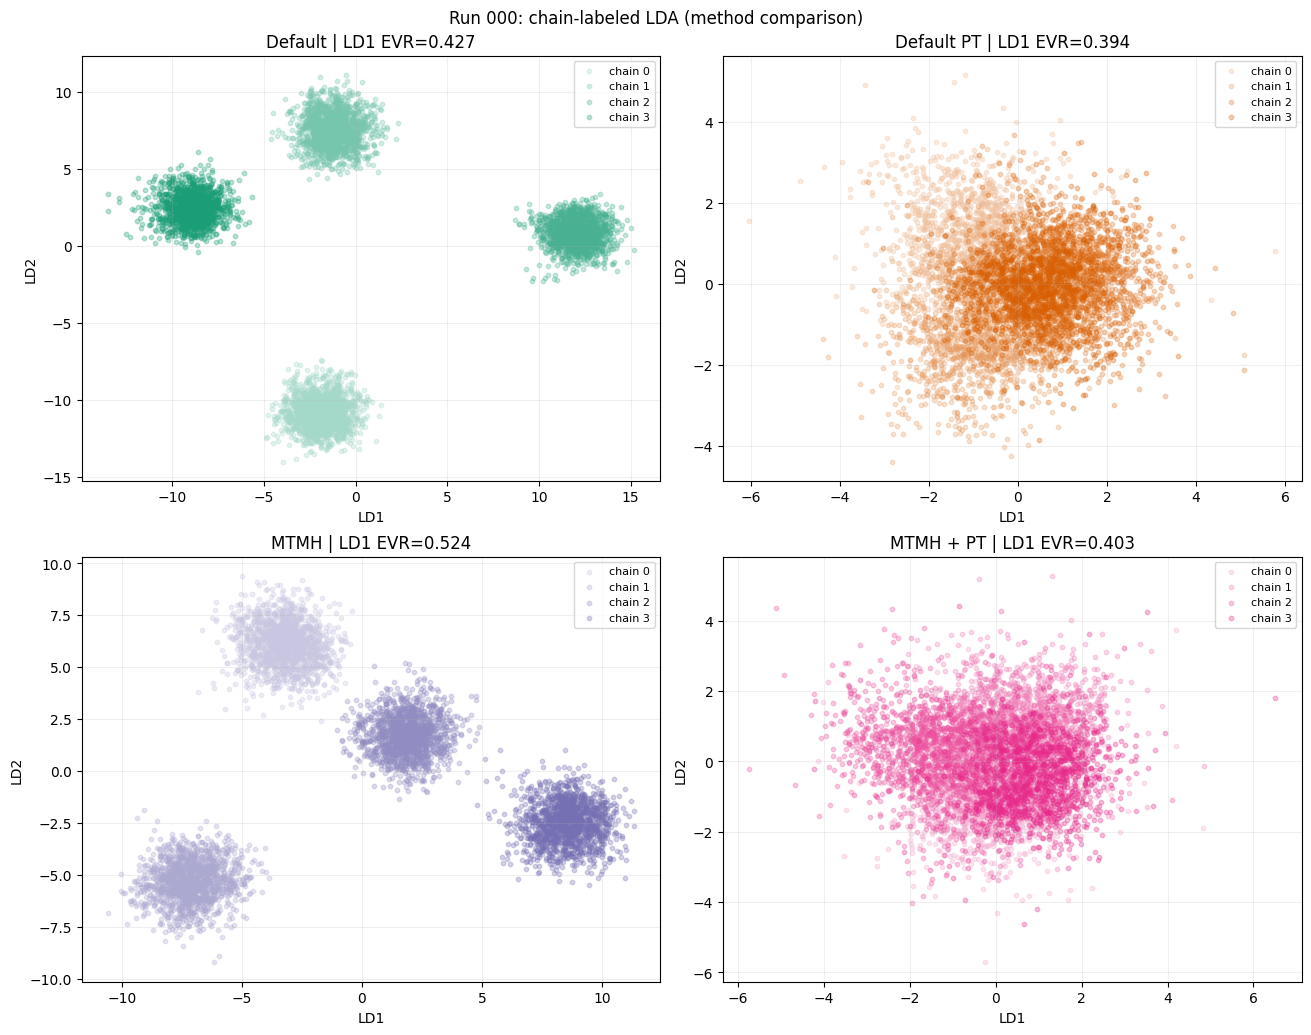

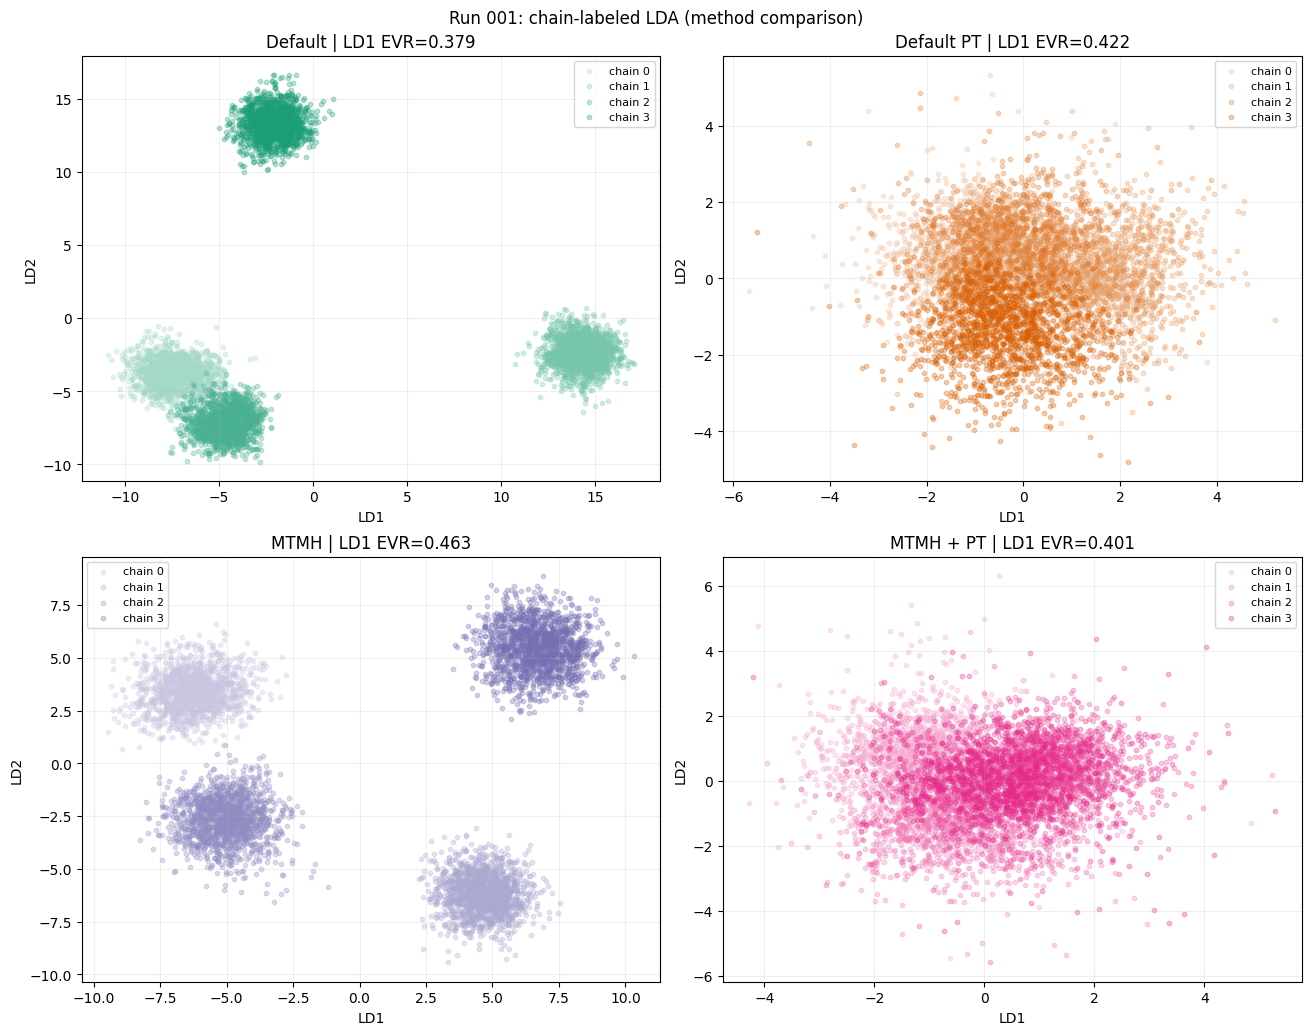

In [10]:
# Method comparison: fixed run, compare four methods in a 2x2 panel
for run_id in RUN_IDS:
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

    for ax, method in zip(axes.flat, SHORT_METHODS):
        X, y, _ = _build_chain_labeled_matrix(
            run_id=run_id,
            method=method,
            max_draws_per_chain=LDA_MAX_DRAWS_PER_CHAIN,
            seed=LDA_RANDOM_SEED + run_id,
        )
        Z, model = _fit_chain_lda(X, y, n_components=2)

        chain_ids = np.unique(y)
        colors = _chain_colors_for_method(method, len(chain_ids))

        if Z.ndim == 1 or Z.shape[1] == 1:
            xvals = Z[:, 0] if Z.ndim > 1 else Z
            jitter = np.random.default_rng(0).normal(0, 0.02, size=xvals.shape[0])
            for cid, color in zip(chain_ids, colors):
                mask = y == cid
                ax.scatter(xvals[mask], jitter[mask], s=10, alpha=0.30, color=color, label=f"chain {cid}")
            ax.set_xlabel("LD1")
            ax.set_ylabel("jitter")
        else:
            for cid, color in zip(chain_ids, colors):
                mask = y == cid
                ax.scatter(Z[mask, 0], Z[mask, 1], s=10, alpha=0.30, color=color, label=f"chain {cid}")
            ax.set_xlabel("LD1")
            ax.set_ylabel("LD2")

        ld1_evr = _lda_explained_var_ld1(model)
        ld1_msg = f"LD1 EVR={ld1_evr:.3f}" if np.isfinite(ld1_evr) else "LD1 EVR=NA"
        ax.set_title(f"{_method_name(method)} | {ld1_msg}")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    fig.suptitle(
        f"Run {run_id:03d}: chain-labeled LDA (method comparison)",
        y=1.02,
    )
    plt.show()


In [11]:
# Compact numeric summary: chain separability per (run, method)
lda_rows = []

for run_id in RUN_IDS:
    for method in SHORT_METHODS:
        X, y, _ = _build_chain_labeled_matrix(
            run_id=run_id,
            method=method,
            max_draws_per_chain=LDA_MAX_DRAWS_PER_CHAIN,
            seed=LDA_RANDOM_SEED + run_id,
        )
        Z, model = _fit_chain_lda(X, y, n_components=2)
        metrics = _chain_separation_metrics(Z, y)

        lda_rows.append(
            {
                "run": f"Run {run_id:03d}",
                "method": _method_name(method),
                "n_samples": int(X.shape[0]),
                "n_features": int(X.shape[1]),
                "ld1_explained_ratio": _lda_explained_var_ld1(model),
                "mean_centroid_distance": metrics["mean_centroid_distance"],
                "between_within_ratio": metrics["between_within_ratio"],
            }
        )

lda_summary_df = pd.DataFrame(lda_rows)
print("LDA chain-separation summary (bigger centroid distance / bigger between_within ratio => stronger chain separation)")
display(lda_summary_df.round(4))

print("\nMean over runs by method")
display(
    lda_summary_df.groupby("method", as_index=False)[
        ["ld1_explained_ratio", "mean_centroid_distance", "between_within_ratio"]
    ]
    .mean()
    .round(4)
)

print("\nPivot: mean_centroid_distance")
display(
    lda_summary_df.pivot_table(
        index="run",
        columns="method",
        values="mean_centroid_distance",
        aggfunc="mean",
    ).round(4)
)

print("\nPivot: between_within_ratio")
display(
    lda_summary_df.pivot_table(
        index="run",
        columns="method",
        values="between_within_ratio",
        aggfunc="mean",
    ).round(4)
)


LDA chain-separation summary (bigger centroid distance / bigger between_within ratio => stronger chain separation)


,run,method,n_samples,n_features,ld1_explained_ratio,mean_centroid_distance,between_within_ratio
0,Run 000,Default,6000,100,0.4270,16.0953,51.2164
1,Run 000,Default PT,6000,100,0.3937,1.8713,0.7133
2,Run 000,MTMH,6000,100,0.5242,11.4230,26.5135
3,Run 000,MTMH + PT,6000,100,0.4026,1.8658,0.6930
4,Run 001,Default,6000,100,0.3793,17.7586,66.3874
5,Run 001,Default PT,6000,100,0.4221,2.0238,0.8461
6,Run 001,MTMH,6000,100,0.4631,11.6927,27.1806
7,Run 001,MTMH + PT,6000,100,0.4009,1.8294,0.6754



Mean over runs by method


,method,ld1_explained_ratio,mean_centroid_distance,between_within_ratio
0,Default,0.4031,16.9270,58.8019
1,Default PT,0.4079,1.9475,0.7797
2,MTMH,0.4937,11.5578,26.8470
3,MTMH + PT,0.4017,1.8476,0.6842



Pivot: mean_centroid_distance


method,Default,Default PT,MTMH,MTMH + PT
run,,,,
Run 000,16.0953,1.8713,11.4230,1.8658
Run 001,17.7586,2.0238,11.6927,1.8294



Pivot: between_within_ratio


method,Default,Default PT,MTMH,MTMH + PT
run,,,,
Run 000,51.2164,0.7133,26.5135,0.6930
Run 001,66.3874,0.8461,27.1806,0.6754
